### DecisionTree (CART) Class

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Represents a node in the Decision Tree
class TreeNode():
    def __init__(self, gini, num_samples, num_samples_class, class_label):
        self.gini = gini  # Gini impurity of the node
        self.num_samples = num_samples # Number of samples in this node
        self.num_samples_class = num_samples_class # Count of samples per class in this node
        self.class_label = class_label # Predicted class label for this node
        self.feature_idx = 0 # Index of the feature to split on (if this is a split node)
        self.threshold = 0  # Threshold value for the split (if this is a split node)
        self.left = None # Left child node
        self.right = None # Right child node

# Implements a Decision Tree Classifier using the CART algorithm
class DecisionTreeClassifier():
    def __init__(self, max_depth = None):
        self.max_depth = max_depth # Maximum depth of the tree
        self.num_classes = None    # Number of unique classes in the target variable
        self.num_features = None   # Number of features in the input data
        self.tree = None           # The root node of the decision tree

    # Finds the best split point (feature and threshold) for a given dataset
    def best_split(self, X_train, y_train):
        m = y_train.size
        # If node is too small or pure, no further split is needed
        if m <= 1:
            return None, None

        # Count samples per class in the current node
        mk = [np.sum(y_train == k) for k in range(self.num_classes)]

        # Calculate initial Gini impurity for the current node
        best_gini = 1.0 - sum((n / m) ** 2 for n in mk)
        best_idx, best_thr = None, None

        # Iterate over all features to find the best split
        for idx in range(self.num_features):
            # Sort data along the selected feature to find potential thresholds
            thresholds, classes = zip(*sorted(zip(X_train[:, idx], y_train)))

            num_left = [0] * self.num_classes  # Counts for the left child node
            num_right = mk.copy()              # Counts for the right child node (initially same as parent)

            # Iterate over all possible split positions for the current feature
            for i in range(1, m):
                k = classes[i - 1]
                num_left[k] += 1
                num_right[k] -= 1

                # Calculate Gini impurity for the left child
                gini_left = 1.0 - sum(
                    (num_left[x] / i) ** 2 for x in range(self.num_classes)
                )
                # Calculate Gini impurity for the right child
                gini_right = 1.0 - sum(
                    (num_right[x] / (m - i)) ** 2 for x in range(self.num_classes)
                )

                # Calculate weighted average Gini impurity for the split
                gini = (i * gini_left + (m - i) * gini_right) / m

                # Skip if current and previous threshold values are identical to avoid redundant splits
                if thresholds[i] == thresholds[i - 1]:
                    continue

                # Update best split if current split is better
                if gini < best_gini:
                    best_gini = gini
                    best_idx = idx
                    best_thr = (thresholds[i] + thresholds[i - 1]) / 2  # Midpoint as threshold

        return best_idx, best_thr

    # Calculates the Gini impurity for a given set of labels
    def gini(self, y_train):
        m = y_train.size
        if m == 0:  # Handle empty node to avoid division by zero
            return 0.0
        return 1.0 - sum((np.sum(y_train == k) / m) ** 2 for k in range(self.num_classes))

    # Trains the decision tree classifier
    def fit(self, X_train, y_train):
        self.num_classes = len(set(y_train)) # Determine number of unique classes
        self.num_features = X_train.shape[1]  # Determine number of features
        self.tree = self.grow_tree(X_train, y_train) # Build the tree recursively

    # Recursively builds the decision tree
    def grow_tree(self, X_train, y_train, depth=0):
        # Count samples per class in the current node
        num_samples_class = [np.sum(y_train == k) for k in range(self.num_classes)]
        class_label = np.argmax(num_samples_class) # Majority class for prediction

        # Create a new tree node
        node = TreeNode(
            gini=self.gini(y_train),
            num_samples=y_train.size,
            num_samples_class=num_samples_class,
            class_label=class_label,
        )

        # Split recursively until maximum depth is reached or node is pure
        if depth < self.max_depth:
            idx, thr = self.best_split(X_train, y_train)
            if idx is not None: # If a valid split is found
                # Split data based on the chosen feature and threshold
                indices_left = X_train[:, idx] < thr
                X_left, y_left = X_train[indices_left], y_train[indices_left]
                X_right, y_right = X_train[~indices_left], y_train[~indices_left]

                # Set node's splitting criteria and build child nodes
                node.feature_idx = idx
                node.threshold = thr
                node.left = self.grow_tree(X_left, y_left, depth + 1)
                node.right = self.grow_tree(X_right, y_right, depth + 1)

        return node

    # Predicts class labels for a given set of test samples
    def predict(self, X_test):
        return [self.predict_helper(x_test) for x_test in X_test]

    # Helper function to predict class label for a single sample by traversing the tree
    def predict_helper(self, x_test):
        node = self.tree
        # Traverse the tree until a leaf node is reached
        while node.left:
            if x_test[node.feature_idx] < node.threshold:
                node = node.left
            else:
                node = node.right
        return node.class_label


# Load the Iris dataset
iris = load_iris()
X = iris.data[:, [2,3]] # Using petal length and petal width
y = iris.target       # Target variable (species)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
print("decision tree classifier...")
tree_clf = DecisionTreeClassifier(max_depth = 3)
tree_clf.fit(X_train, y_train)

# Make predictions on the test set
print("prediction...")
y_pred = tree_clf.predict(X_test)

# Evaluate the accuracy of the classifier
tree_clf_acc = accuracy_score(y_test, y_pred)
print("test set accuracy: ", tree_clf_acc)


decision tree classifier...
prediction...
test set accuracy:  1.0


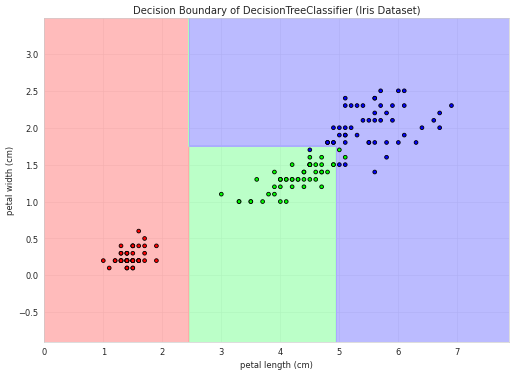

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load Iris data again (or ensure X, y from previous cell are available)
iris = load_iris()
X = iris.data[:, [2, 3]] # Petal length and petal width
y = iris.target

# Retrain the decision tree classifier on the full dataset for a cleaner boundary visualization
# Or use the previously trained one if X_train/y_train matches the visualization scope
tree_clf_viz = DecisionTreeClassifier(max_depth=3)
tree_clf_viz.fit(X, y)

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFBB', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Plot the decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = tree_clf_viz.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = np.array(Z).reshape(xx.shape)
plt.figure(figsize=(10, 7), dpi=60)
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("Decision Boundary of DecisionTreeClassifier (Iris Dataset)")
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()